# WildChat Plots by Model (Raw Names)

Analysis of tasks and sensitive information by model version (no grouping).

**Prerequisites:**
1. Run: `python extract_models_for_hashes.py` (creates conversation_hash_to_model.csv)
2. Have these files in the current directory:
   - `task_annotations.csv`
   - `processed_sensitive_info_annotations.csv`
   - `conversation_hash_to_model.csv` (created by extraction script)


## 1. Setup & Load Data

In [21]:
from collections import defaultdict
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set(style='ticks', font_scale=1.2)
%matplotlib inline

output_directory_path = '.'  # Set this to your output directory if saving plots

In [22]:
# Load data files
print("Loading data files...")

# Check files exist
required_files = ['task_annotations.csv', 'processed_sensitive_info_annotations.csv', 'conversation_hash_to_model.csv']
for f in required_files:
    if not os.path.exists(f):
        print(f"❌ Missing: {f}")
        print(f"   Run: python extract_models_for_hashes.py")
        raise FileNotFoundError(f)

tasks_annotated_df = pd.read_csv('task_annotations.csv')
sensitive_annotated_df = pd.read_csv('processed_sensitive_info_annotations.csv')
model_df = pd.read_csv('conversation_hash_to_model.csv')

print(f"✓ Task annotations: {len(tasks_annotated_df)} rows")
print(f"✓ Sensitive annotations: {len(sensitive_annotated_df)} rows")
print(f"✓ Model mapping: {len(model_df)} rows")

Loading data files...
✓ Task annotations: 7920 rows
✓ Sensitive annotations: 3922 rows
✓ Model mapping: 4252 rows


## 2. Merge Model Information

In [23]:
# Create model dictionary for mapping
model_dict = dict(zip(model_df['conversation_hash'], model_df['model']))

# Add model to tasks
tasks_annotated_df['model'] = tasks_annotated_df['conversation_hash'].map(model_dict)

# Add model to sensitive
sensitive_annotated_df['model'] = sensitive_annotated_df['conversation_hash'].map(model_dict)

print(f"Tasks with model info: {tasks_annotated_df['model'].notna().sum()}/{len(tasks_annotated_df)}")
print(f"Sensitive with model info: {sensitive_annotated_df['model'].notna().sum()}/{len(sensitive_annotated_df)}")

print(f"\nModels in task annotations:")
print(tasks_annotated_df['model'].value_counts())

print(f"\nModels in sensitive disclosures:")
print(sensitive_annotated_df['model'].value_counts())

Tasks with model info: 6678/7920
Sensitive with model info: 3149/3922

Models in task annotations:
model
gpt-3.5-turbo-0613    2818
gpt-3.5-turbo-0301    1642
gpt-4-1106-preview     873
gpt-4-0314             589
gpt-4-0125-preview     582
gpt-3.5-turbo-0125     174
Name: count, dtype: int64

Models in sensitive disclosures:
model
gpt-3.5-turbo-0613    1366
gpt-3.5-turbo-0301     732
gpt-4-1106-preview     402
gpt-4-0314             314
gpt-4-0125-preview     262
gpt-3.5-turbo-0125      73
Name: count, dtype: int64


## 3. Task Distribution by Model

In [24]:
# Build task-model comparison table
task_model_comparison = defaultdict(lambda: defaultdict(int))

for i, r in tasks_annotated_df.iterrows():
    model = r['model']
    if pd.isna(model):
        continue
    # Use predicted_category as-is (one task per row)
    # Do NOT split on commas - categories may contain commas in parentheses
    _task = str(r['predicted_category']).strip()
    if _task and _task != 'nan':
        task_model_comparison[_task][model] += 1

# Convert to DataFrame
task_model_df = pd.DataFrame(task_model_comparison).T
task_model_df['total'] = task_model_df.sum(axis=1)
task_model_df = task_model_df.sort_values('total', ascending=False)

print("\\nTop 10 tasks by frequency:")
print(task_model_df.head(10))

\nTop 10 tasks by frequency:
                                                    gpt-3.5-turbo-0613  \
explanation, how-to, practical advice                            590.0   
information retrieval                                            477.0   
code generation                                                  192.0   
editing existing text                                            228.0   
code editing and debugging                                       136.0   
generating non-fictional documents (resumes, es...               172.0   
translation                                                      138.0   
story and script generation                                      109.0   
brainstorming and generating ideas                               105.0   
generating communications (email, text messages...               127.0   

                                                    gpt-3.5-turbo-0301  \
explanation, how-to, practical advice                            353.0   
informat

Saved: tasks_by_model_comparison.pdf


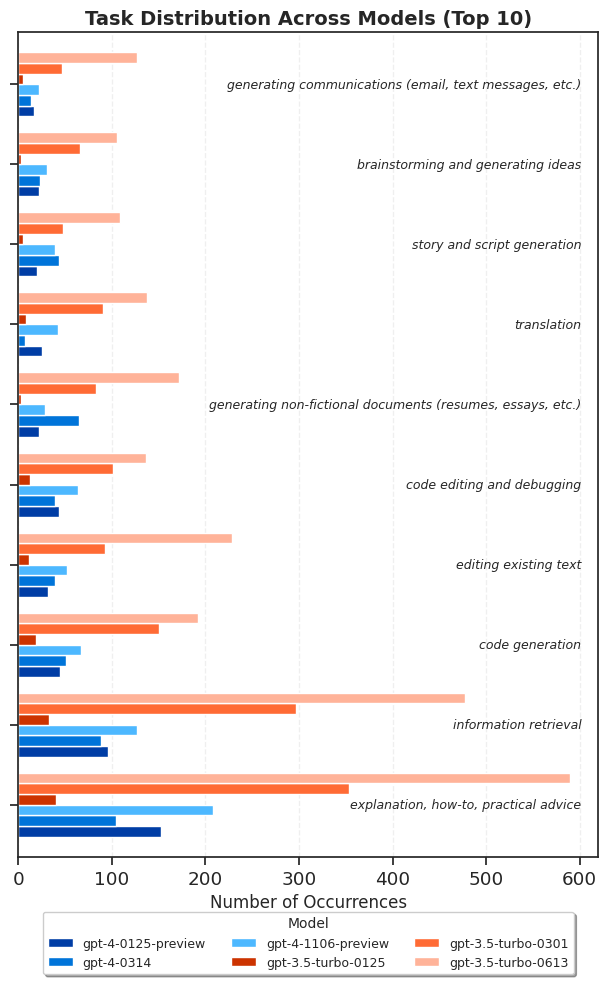

In [25]:
# Plot task distribution - unified style with grouped models (GPT-4 together, GPT-3.5 together)
models_with_data = [col for col in task_model_df.columns if col != 'total' and task_model_df[col].sum() > 0]
top_tasks = task_model_df.head(10)[models_with_data]

# Sort columns: GPT-4 variants first, then GPT-3.5 variants, then others
def sort_models(models):
    gpt4 = sorted([m for m in models if 'gpt-4' in m.lower()])
    gpt35 = sorted([m for m in models if 'gpt-3' in m.lower()])
    others = sorted([m for m in models if 'gpt-4' not in m.lower() and 'gpt-3' not in m.lower()])
    return gpt4 + gpt35 + others

sorted_models = sort_models(models_with_data)
top_tasks = top_tasks[sorted_models]

# Create color mapping: Different colors per model, but similar scheme within family
gpt4_colors = ['#003DA5', '#0074D9', '#4DB8FF']  # Dark blue to light blue
gpt35_colors = ['#CC3300', '#FF6B35', '#FFB399']  # Dark orange to light orange
other_colors = ['#999999', '#CCCCCC']

colors = {}
gpt4_idx = 0
gpt35_idx = 0
other_idx = 0

for model in sorted_models:
    if 'gpt-4' in model.lower():
        colors[model] = gpt4_colors[gpt4_idx % len(gpt4_colors)]
        gpt4_idx += 1
    elif 'gpt-3' in model.lower():
        colors[model] = gpt35_colors[gpt35_idx % len(gpt35_colors)]
        gpt35_idx += 1
    else:
        colors[model] = other_colors[other_idx % len(other_colors)]
        other_idx += 1

color_list = [colors[model] for model in sorted_models]

fig, ax = plt.subplots(figsize=(6.5, 10))
top_tasks.plot(kind='barh', ax=ax, width=0.8, color=color_list)

# Remove y-axis labels (we'll put them on the right side)
ax.set_yticklabels([])

# Get the maximum value across all data to position labels consistently
max_overall = top_tasks[sorted_models].max().max()
label_x_pos = max_overall * 1.02  # Position labels slightly to the right of longest bar

# Add task names to the right of bars, RIGHT-ALIGNED
for i, task_name in enumerate(top_tasks.index):
    ax.text(label_x_pos, i, task_name, va='center', ha='right', fontsize=9, style='italic')

ax.set_xlabel('Number of Occurrences', fontsize=12)
ax.set_ylabel('')
ax.set_title('Task Distribution Across Models (Top 10)', fontsize=14, fontweight='bold')

# Legend at BOTTOM (horizontal)
ax.legend(title='Model', bbox_to_anchor=(0.5, -0.15), loc='lower center', ncol=3, 
          fontsize=9, title_fontsize=10, frameon=True, fancybox=True, shadow=True)

# Add grid for easier reading
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Add margins
ax.margins(y=0.01)

plt.tight_layout()

if output_directory_path and os.path.exists(output_directory_path + '/plots'):
    plt.savefig(output_directory_path + '/plots/tasks_by_model_comparison.pdf', bbox_inches='tight', dpi=150)
    print("Saved: tasks_by_model_comparison.pdf")

plt.show()

## 4. Sensitive Categories Distribution by Model

In [26]:
# Build sensitive-model comparison table
sensitive_model_comparison = defaultdict(lambda: defaultdict(int))

for i, r in sensitive_annotated_df.iterrows():
    model = r['model']
    if pd.isna(model):
        continue
    _category = r['predicted_category']
    if pd.notna(_category):
        sensitive_model_comparison[_category][model] += 1

# Convert to DataFrame
sensitive_model_df = pd.DataFrame(sensitive_model_comparison).T
sensitive_model_df['total'] = sensitive_model_df.sum(axis=1)
sensitive_model_df = sensitive_model_df.sort_values('total', ascending=False)

print("\nSensitive categories by frequency:")
print(sensitive_model_df)


Sensitive categories by frequency:
                                   gpt-3.5-turbo-0301  gpt-3.5-turbo-0613  \
academic and education info                     241.0               488.0   
quoted code                                     195.0               238.0   
fandom                                           68.0               153.0   
financial and corporate info                     63.0               127.0   
user's hobbies and habits                        58.0                91.0   
job, visa, and other applications                32.0                92.0   
healthcare information                           26.0                59.0   
quoted emails and messages                       22.0                52.0   
user's personal relationships                    17.0                40.0   
user's emotions and mental health                 4.0                17.0   
sexual and erotic content                         5.0                 5.0   
user's politics and religion            

Saved: sensitive_by_model_comparison.pdf


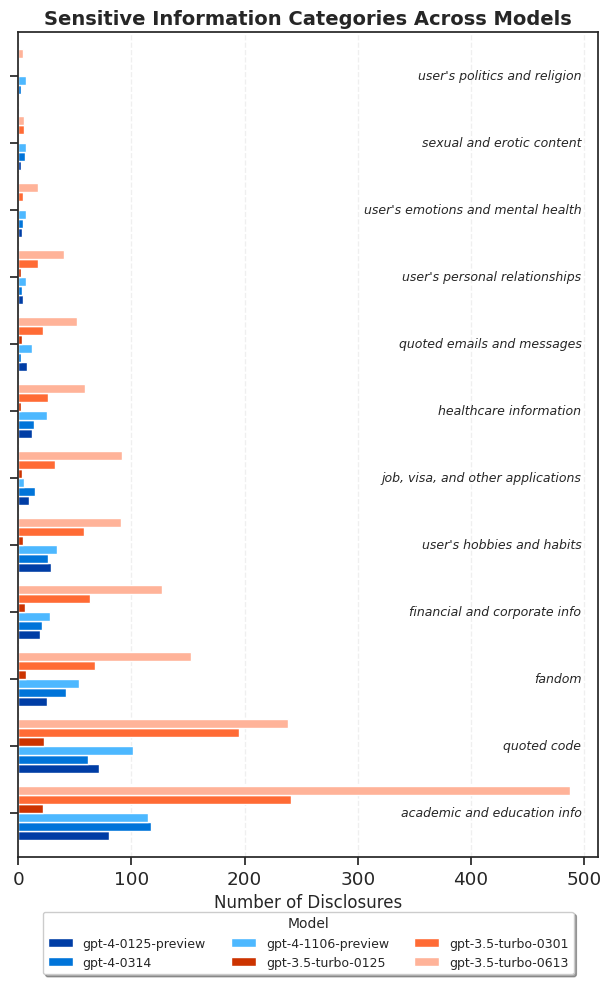

In [27]:
# Plot sensitive categories - unified style with grouped models (GPT-4 together, GPT-3.5 together)
models_with_data = [col for col in sensitive_model_df.columns if col != 'total' and sensitive_model_df[col].sum() > 0]
sensitive_comparison = sensitive_model_df[models_with_data]

# Sort columns: GPT-4 variants first, then GPT-3.5 variants, then others
def sort_models(models):
    gpt4 = sorted([m for m in models if 'gpt-4' in m.lower()])
    gpt35 = sorted([m for m in models if 'gpt-3' in m.lower()])
    others = sorted([m for m in models if 'gpt-4' not in m.lower() and 'gpt-3' not in m.lower()])
    return gpt4 + gpt35 + others

sorted_models = sort_models(models_with_data)
sensitive_comparison = sensitive_comparison[sorted_models]

# Create color mapping: Different colors per model, but similar scheme within family
gpt4_colors = ['#003DA5', '#0074D9', '#4DB8FF']  # Dark blue to light blue
gpt35_colors = ['#CC3300', '#FF6B35', '#FFB399']  # Dark orange to light orange
other_colors = ['#999999', '#CCCCCC']

colors = {}
gpt4_idx = 0
gpt35_idx = 0
other_idx = 0

for model in sorted_models:
    if 'gpt-4' in model.lower():
        colors[model] = gpt4_colors[gpt4_idx % len(gpt4_colors)]
        gpt4_idx += 1
    elif 'gpt-3' in model.lower():
        colors[model] = gpt35_colors[gpt35_idx % len(gpt35_colors)]
        gpt35_idx += 1
    else:
        colors[model] = other_colors[other_idx % len(other_colors)]
        other_idx += 1

color_list = [colors[model] for model in sorted_models]

fig, ax = plt.subplots(figsize=(6.5, 10))
sensitive_comparison.plot(kind='barh', ax=ax, width=0.8, color=color_list)

# Remove y-axis labels (we'll put them on the right side)
ax.set_yticklabels([])

# Get the maximum value across all data to position labels consistently
max_overall = sensitive_comparison[sorted_models].max().max()
label_x_pos = max_overall * 1.02  # Position labels slightly to the right of longest bar

# Add category names to the right of bars, RIGHT-ALIGNED
for i, cat_name in enumerate(sensitive_comparison.index):
    ax.text(label_x_pos, i, cat_name, va='center', ha='right', fontsize=9, style='italic')

ax.set_xlabel('Number of Disclosures', fontsize=12)
ax.set_ylabel('')
ax.set_title('Sensitive Information Categories Across Models', fontsize=14, fontweight='bold')

# Legend at BOTTOM (horizontal)
ax.legend(title='Model', bbox_to_anchor=(0.5, -0.15), loc='lower center', ncol=3,
          fontsize=9, title_fontsize=10, frameon=True, fancybox=True, shadow=True)

# Add grid for easier reading
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Add margins
ax.margins(y=0.01)

plt.tight_layout()

if output_directory_path and os.path.exists(output_directory_path + '/plots'):
    plt.savefig(output_directory_path + '/plots/sensitive_by_model_comparison.pdf', bbox_inches='tight', dpi=150)
    print("Saved: sensitive_by_model_comparison.pdf")

plt.show()

## 5. Heatmaps: Tasks × Sensitive Categories (by Model)

Creating heatmaps for 6 models...

✓ Heatmap for gpt-3.5-turbo-0125


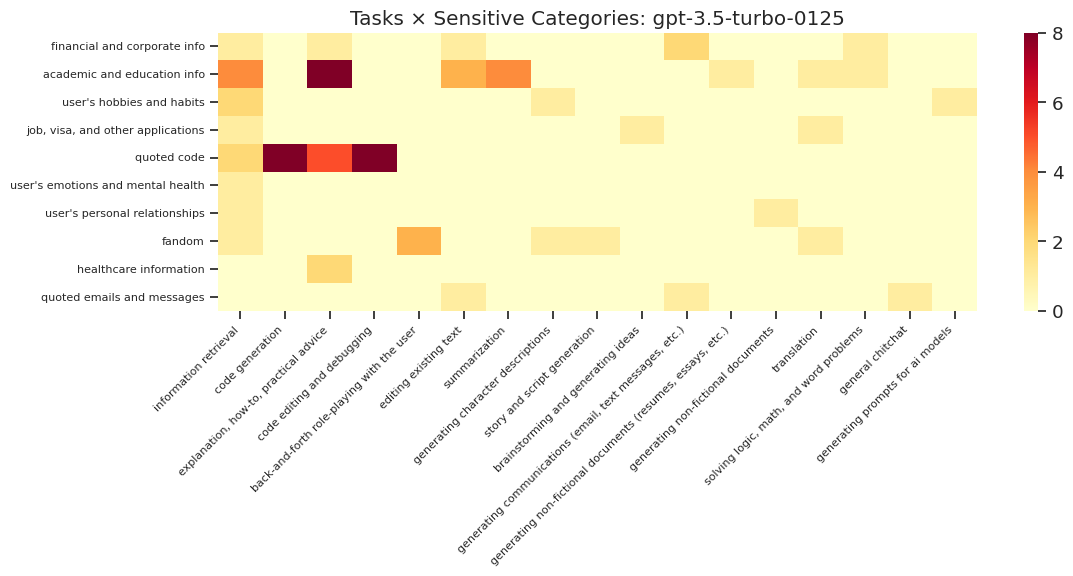

✓ Heatmap for gpt-3.5-turbo-0301


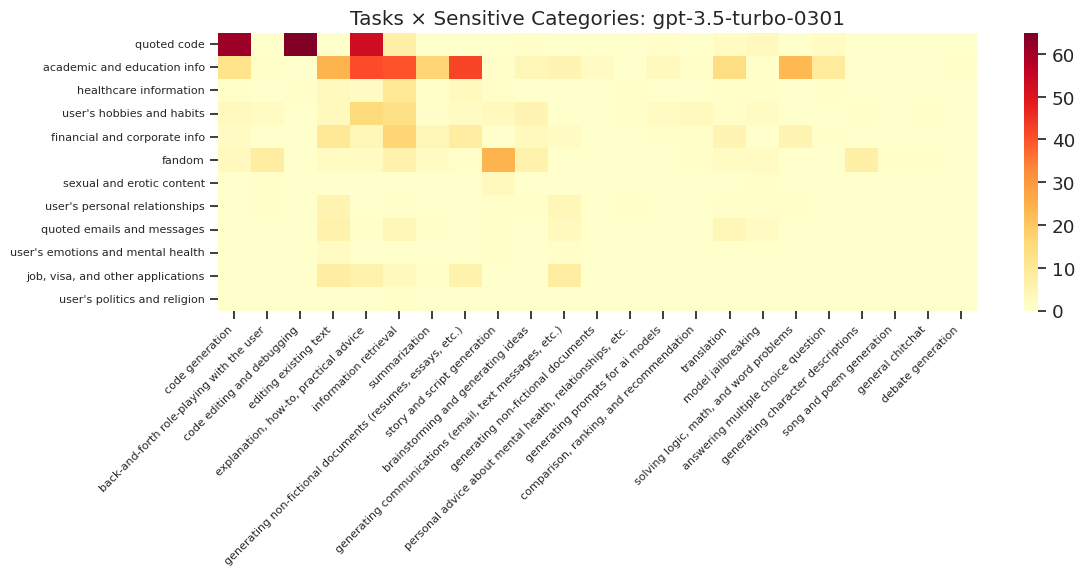

✓ Heatmap for gpt-3.5-turbo-0613


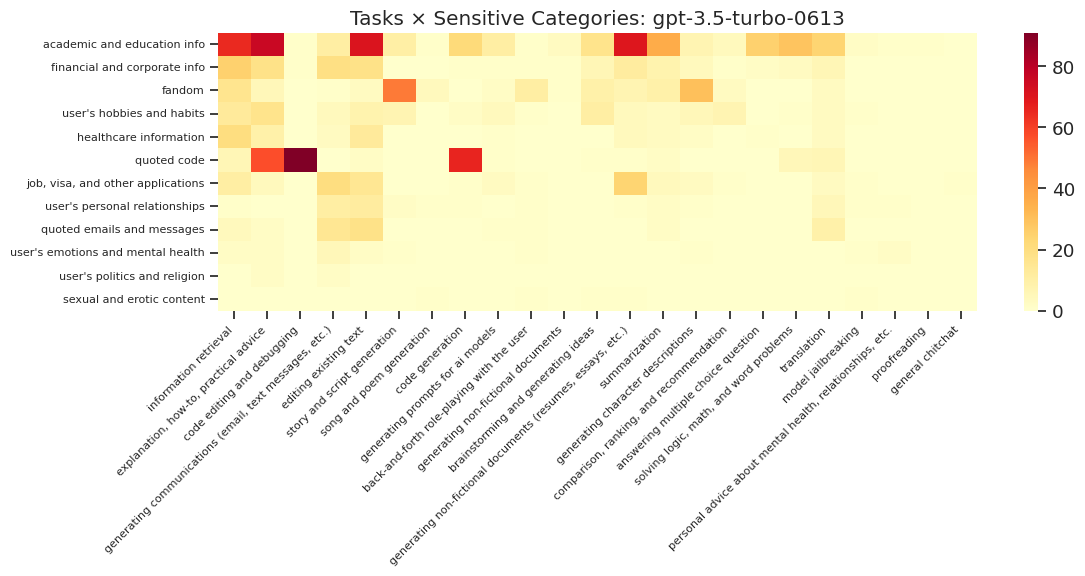

✓ Heatmap for gpt-4-0125-preview


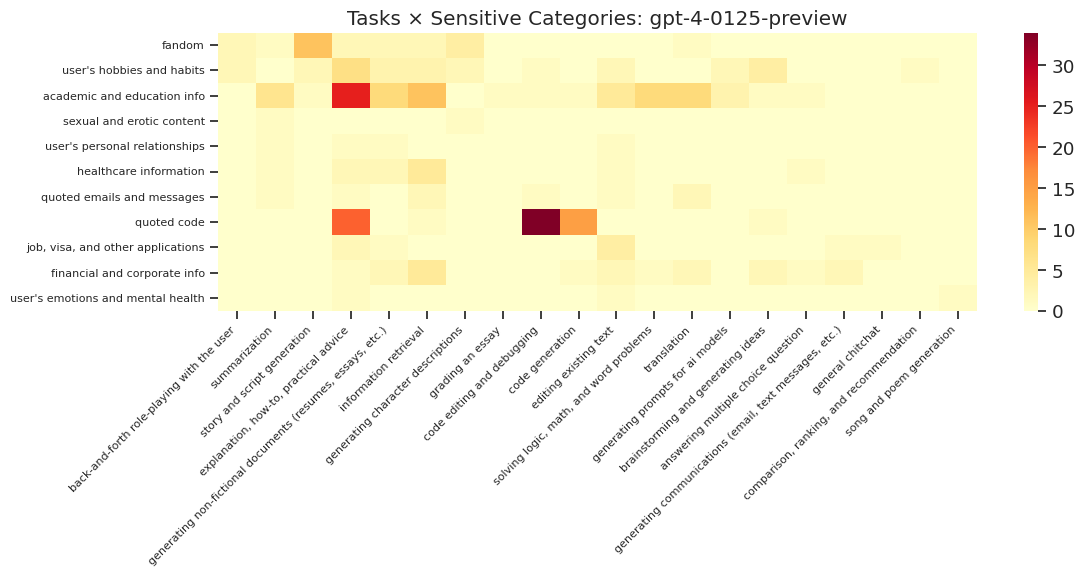

✓ Heatmap for gpt-4-0314


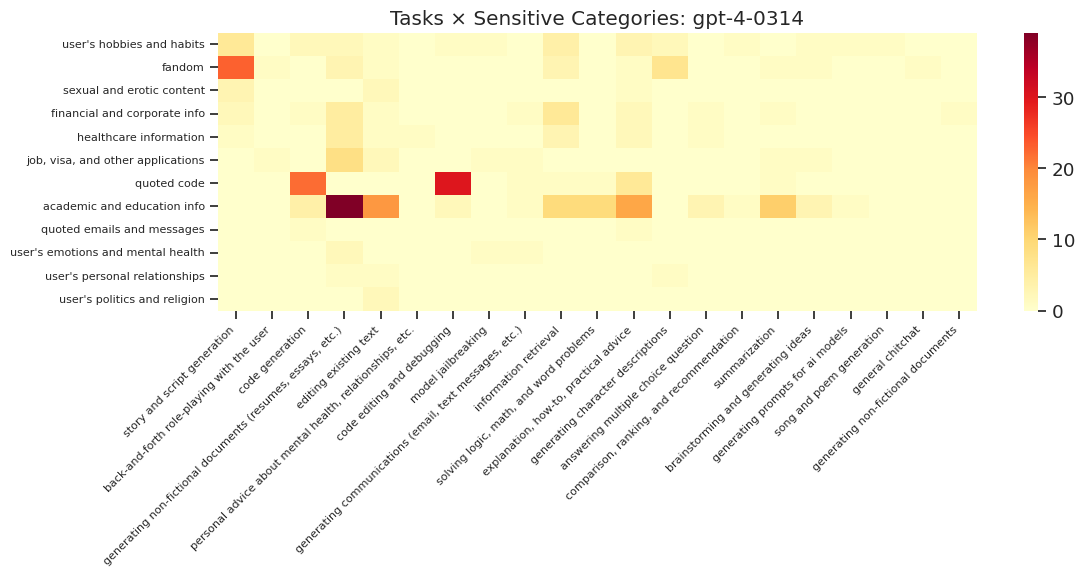

✓ Heatmap for gpt-4-1106-preview


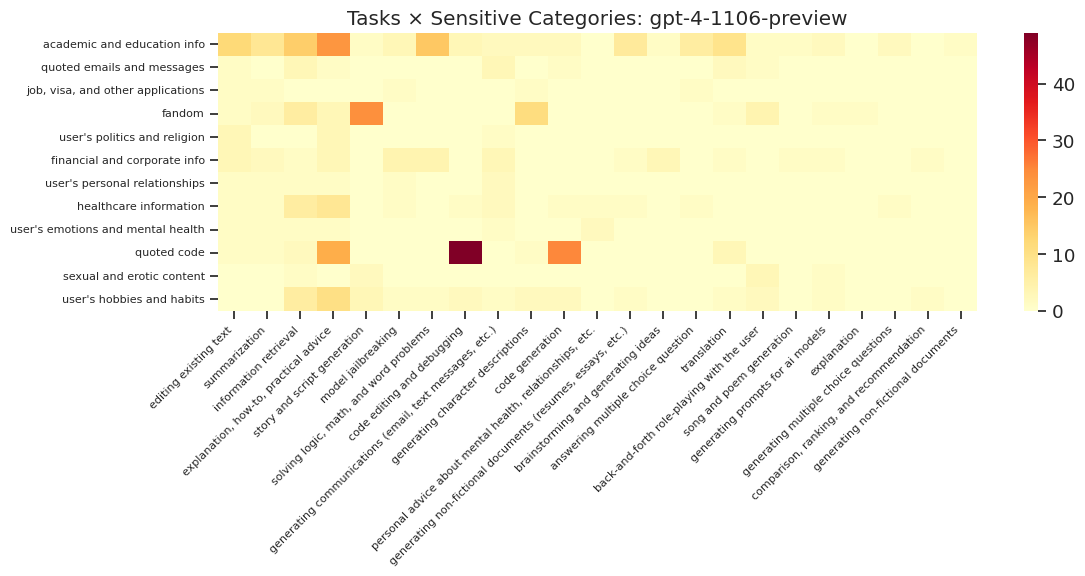

In [28]:
def create_task_sensitive_heatmap(tasks_df, sensitive_df, model_name):
    """Create heatmap of tasks x sensitive categories for a specific model"""
    
    # Filter by model
    tasks_filtered = tasks_df[tasks_df['model'] == model_name]
    sensitive_filtered = sensitive_df[sensitive_df['model'] == model_name]
    
    if len(tasks_filtered) == 0 or len(sensitive_filtered) == 0:
        return None, None
    
    # Build task-sensitive matrix
    matrix_dict = defaultdict(lambda: defaultdict(int))
    
    for conv_hash in tasks_filtered['conversation_hash'].unique():
        task_row = tasks_filtered[tasks_filtered['conversation_hash'] == conv_hash]
        if len(task_row) == 0:
            continue
        
        # Use task as-is (no splitting on commas)
        task = str(task_row.iloc[0]['predicted_category']).strip()
        if not task or task == 'nan':
            continue
        
        sensitive_rows = sensitive_filtered[sensitive_filtered['conversation_hash'] == conv_hash]
        
        if len(sensitive_rows) == 0:
            continue
        
        for _, sensitive_row in sensitive_rows.iterrows():
            sensitive_cat = sensitive_row['predicted_category']
            if pd.notna(sensitive_cat):
                matrix_dict[task][sensitive_cat] += 1
    
    if not matrix_dict:
        return None, None
    
    matrix_df = pd.DataFrame(matrix_dict).fillna(0)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.heatmap(matrix_df, cmap='YlOrRd', cbar=True, ax=ax, annot=False)
    ax.set_title(f'Tasks × Sensitive Categories: {model_name}')
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    
    return fig, matrix_df

# Create heatmaps for each model
models_to_plot = sorted(tasks_annotated_df['model'].dropna().unique())
print(f"Creating heatmaps for {len(models_to_plot)} models...\n")

for model in models_to_plot:
    fig, matrix = create_task_sensitive_heatmap(tasks_annotated_df, sensitive_annotated_df, model)
    if fig is not None:
        safe_model_name = model.replace('/', '_').replace(' ', '_').replace('.', '_')
        print(f"✓ Heatmap for {model}")
        
        if output_directory_path and os.path.exists(output_directory_path + '/plots'):
            plt.savefig(output_directory_path + f'/plots/heatmap_tasks_x_sensitive_{safe_model_name}.pdf', bbox_inches='tight')
        
        plt.show()
    else:
        print(f"⊘ No data for {model}")

## 6. Explicit vs Implicit PII (by Model)

In [29]:
# Check if explicit/implicit column exists
if 'explicit_or_implicit' in sensitive_annotated_df.columns:
    explicit_implicit_by_model = defaultdict(lambda: {'explicit': 0, 'implicit': 0})
    
    for i, r in sensitive_annotated_df.iterrows():
        model = r['model']
        if pd.isna(model):
            continue
        ei = str(r['explicit_or_implicit']).strip().lower()
        if ei in ['explicit', 'implicit']:
            explicit_implicit_by_model[model][ei] += 1
    
    ei_df = pd.DataFrame(explicit_implicit_by_model).T
    
    print("\nExplicit vs Implicit by Model:")
    print(ei_df)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    ei_df.plot(kind='bar', ax=ax, color=['#0074D9', '#FF4136'])
    ax.set_xlabel('Model')
    ax.set_ylabel('Number of Disclosures')
    ax.set_title('Explicit vs Implicit PII Leakage by Model')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    plt.legend(['Explicit', 'Implicit'])
    plt.tight_layout()
    
    if output_directory_path and os.path.exists(output_directory_path + '/plots'):
        plt.savefig(output_directory_path + '/plots/explicit_vs_implicit_by_model.pdf', bbox_inches='tight')
        print("\nSaved: explicit_vs_implicit_by_model.pdf")
    
    plt.show()
else:
    print("No explicit_or_implicit column in sensitive data")

No explicit_or_implicit column in sensitive data


## 7. Summary Statistics

In [30]:
print("=" * 80)
print("SUMMARY STATISTICS BY MODEL (RAW NAMES)")
print("=" * 80)

models_in_data = sorted(tasks_annotated_df['model'].dropna().unique())

for model in models_in_data:
    tasks_count = (tasks_annotated_df['model'] == model).sum()
    sensitive_count = (sensitive_annotated_df['model'] == model).sum()
    unique_convs = len(tasks_annotated_df[tasks_annotated_df['model'] == model]['conversation_hash'].unique())
    
    print(f"\n{model}:")
    print(f"  Task annotations: {tasks_count}")
    print(f"  Sensitive disclosures: {sensitive_count}")
    print(f"  Unique conversations: {unique_convs}")
    if unique_convs > 0:
        print(f"  Avg sensitive items per conversation: {sensitive_count/unique_convs:.2f}")
    
    # Explicit/implicit ratio if available
    if 'explicit_or_implicit' in sensitive_annotated_df.columns:
        subset = sensitive_annotated_df[sensitive_annotated_df['model'] == model]
        explicit = (subset['explicit_or_implicit'].str.lower() == 'explicit').sum()
        implicit = (subset['explicit_or_implicit'].str.lower() == 'implicit').sum()
        total_ei = explicit + implicit
        if total_ei > 0:
            print(f"  Explicit: {explicit} ({(explicit/total_ei)*100:.1f}%)")
            print(f"  Implicit: {implicit} ({(implicit/total_ei)*100:.1f}%)")
            if explicit > 0:
                print(f"  Ratio (explicit:implicit): 1:{implicit/explicit:.2f}")

print("\n" + "=" * 80)

SUMMARY STATISTICS BY MODEL (RAW NAMES)

gpt-3.5-turbo-0125:
  Task annotations: 174
  Sensitive disclosures: 73
  Unique conversations: 114
  Avg sensitive items per conversation: 0.64

gpt-3.5-turbo-0301:
  Task annotations: 1642
  Sensitive disclosures: 732
  Unique conversations: 998
  Avg sensitive items per conversation: 0.73

gpt-3.5-turbo-0613:
  Task annotations: 2818
  Sensitive disclosures: 1366
  Unique conversations: 1845
  Avg sensitive items per conversation: 0.74

gpt-4-0125-preview:
  Task annotations: 582
  Sensitive disclosures: 262
  Unique conversations: 366
  Avg sensitive items per conversation: 0.72

gpt-4-0314:
  Task annotations: 589
  Sensitive disclosures: 314
  Unique conversations: 394
  Avg sensitive items per conversation: 0.80

gpt-4-1106-preview:
  Task annotations: 873
  Sensitive disclosures: 402
  Unique conversations: 535
  Avg sensitive items per conversation: 0.75

